# **Personality Analysis using HandWritting - A DeepLearning Approach**

In [ ]:
# STEP 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## **Importing Required Libraries**

In [ ]:
# STEP 2: Import Libraries
import os
import cv2
import numpy as np
import pandas as pd
from glob import glob
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops


## **Feature Extraction**

In [ ]:
# STEP 3: Define All Feature Extraction Functions

def extract_slant_angle(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        lines = cv2.HoughLines(edges, 1, np.pi/180, 200)
        if lines is not None:
            angles = [(np.rad2deg(theta) - 90) for rho, theta in lines[:, 0]]
            return np.mean(angles)
    except:
        return 0
    return 0

def letter_spacing_consistency(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        thresh = threshold_otsu(gray)
        binary = gray < thresh
        label_img = label(binary)
        props = regionprops(label_img)
        centers = [prop.centroid[1] for prop in props if prop.area > 30]
        centers.sort()
        gaps = [centers[i+1] - centers[i] for i in range(len(centers)-1)]
        return np.std(gaps) if gaps else 0
    except:
        return 0

def pressure_on_paper(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return 255 - np.mean(gray)
    except:
        return 0

def line_alignment(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        horizontal_projection = np.sum(255 - gray, axis=1)
        variance = np.var(horizontal_projection)
        return variance
    except:
        return 0

def loop_formation(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        loop_count = sum(1 for cnt in contours if cv2.contourArea(cnt) > 10)
        return loop_count
    except:
        return 0

def stroke_smoothness(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
        return np.mean(np.sqrt(sobelx**2 + sobely**2))
    except:
        return 0

def word_spacing_variability(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        projection = np.sum(255 - gray, axis=0)
        gaps = []
        count = 0
        for p in projection:
            if p < 10:
                count += 1
            else:
                if count > 1:
                    gaps.append(count)
                count = 0
        return np.std(gaps) if gaps else 0
    except:
        return 0

def letter_size_consistency(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        heights = [cv2.boundingRect(cnt)[3] for cnt in contours if cv2.contourArea(cnt) > 30]
        return np.std(heights) if heights else 0
    except:
        return 0

def pen_lift_frequency(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
        kernel = np.ones((5,5), np.uint8)
        dilated = cv2.dilate(binary, kernel, iterations=1)
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return len(contours)
    except:
        return 0

def legibility_score(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)
        edges = cv2.Canny(blur, 50, 150)
        return 1 / (1 + np.std(edges))  # inverse of edge variance
    except:
        return 0

def cursive_vs_print(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
        horizontal_sum = np.sum(binary, axis=1)
        return np.std(horizontal_sum)
    except:
        return 0

def speed_fluctuations(img):
    try:
        return stroke_smoothness(img)  # proxy for variation in stroke intensity
    except:
        return 0

def pen_tilt_direction(img):
    try:
        return extract_slant_angle(img)  # proxy for tilt
    except:
        return 0

def ink_darkness_variation(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return np.std(gray)
    except:
        return 0

def strokes_per_letter(img):
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return len(contours)
    except:
        return 0



Slant_Angle,
Letter_Spacing,
Pressure,
Line_Alignment,
Loop_Formation,
Stroke_Smoothness,
Word_Spacing,
Letter_Size_Consistency,
Pen_Lift,
Legibility,
Cursive_Print,
Speed_Fluctuation,
Pen_Tilt,
Strokes_Per_Letter

In [ ]:
# STEP 4: Collect Image Paths

base_dirs = [
    "/content/drive/MyDrive/augmented_train",
    "/content/drive/MyDrive/augmented_test"
]

labels = ['Agreeableness', 'Conscientiousness', 'Extraversion', 'Neuroticism', 'Openness']
image_data = []

for base_dir in base_dirs:
    for label in labels:
        folder = os.path.join(base_dir, label)
        for img_path in glob(f"{folder}/*.jpg"):
            image_data.append((img_path, label))


In [ ]:
# STEP 5: Extract Features and Save to CSV

features_list = []

for img_path, label in image_data:
    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (400, 400))

        features_list.append({
            'image_name': os.path.basename(img_path),
            'label': label,
            'Feature_1_Slant_Angle': extract_slant_angle(img),
            'Feature_2_Letter_Spacing': letter_spacing_consistency(img),
            'Feature_3_Pressure': pressure_on_paper(img),
            'Feature_4_Line_Alignment': line_alignment(img),
            'Feature_5_Loop_Formation': loop_formation(img),
            'Feature_6_Stroke_Smoothness': stroke_smoothness(img),
            'Feature_7_Word_Spacing': word_spacing_variability(img),
            'Feature_8_Letter_Size_Consistency': letter_size_consistency(img),
            'Feature_9_Pen_Lift': pen_lift_frequency(img),
            'Feature_10_Legibility': legibility_score(img),
            'Feature_11_Cursive_Print': cursive_vs_print(img),
            'Feature_12_Speed_Fluctuation': speed_fluctuations(img),
            'Feature_13_Pen_Tilt': pen_tilt_direction(img),
            'Feature_14_Ink_Darkness': ink_darkness_variation(img),
            'Feature_15_Strokes_Per_Letter': strokes_per_letter(img)
        })
    except Exception as e:
        print(f"Error processing {img_path}: {e}")


In [ ]:
# STEP 6: Export to CSV
df = pd.DataFrame(features_list)
output_path = "/content/drive/MyDrive/handwriting_15_features.csv"
df.to_csv(output_path, index=False)
print(f"✅ Features extracted for {len(df)} images and saved to:\n{output_path}")


✅ Features extracted for 4076 images and saved to:
/content/drive/MyDrive/handwriting_15_features.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# === Load the CSV file ===
df = pd.read_csv('/content/handwriting_15_features.csv')

# === Define feature columns ===
feature_cols = [
    'Feature_1_Slant_Angle',
            'Feature_2_Letter_Spacing',
            'Feature_3_Pressure',
            'Feature_4_Line_Alignment',
            'Feature_5_Loop_Formation',
            'Feature_6_Stroke_Smoothness',
            'Feature_7_Word_Spacing',
            'Feature_8_Letter_Size_Consistency',
            'Feature_9_Pen_Lift',
            'Feature_10_Legibility',
            'Feature_11_Cursive_Print',
            'Feature_12_Speed_Fluctuation',
            'Feature_13_Pen_Tilt',
            'Feature_14_Ink_Darkness',
            'Feature_15_Strokes_Per_Letter',
]

# === Encode the personality labels ===
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])

# === Split dataset ===
X = df[feature_cols].values
y = df['encoded_label'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# === Define the Deep Learning model ===
model = Sequential([
    Dense(128, activation='relu', input_shape=(15,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')  # Output layer for 5 personality types
])

# === Compile the model ===
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# === Train the model ===
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

# === Predict and Evaluate ===
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Print classification report ===
print("\n📊 Deep Learning Model Classification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2050 - loss: 2757464.0000 - val_accuracy: 0.1691 - val_loss: 111146.2188
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1899 - loss: 304660.9062 - val_accuracy: 0.1912 - val_loss: 8001.9717
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2147 - loss: 55957.9453 - val_accuracy: 0.2451 - val_loss: 1.6097
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2138 - loss: 15695.2207 - val_accuracy: 0.2451 - val_loss: 1.6105
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2336 - loss: 6136.0562 - val_accuracy: 0.2451 - val_loss: 1.6100
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2415 - loss: 4504.7446 - val_accuracy: 0.2451 - val_loss: 1.6087
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2477 - loss: 4293.9448 - val_accuracy: 0.2451 - val_loss: 1.6070
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2312 - loss: 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# === Load dataset ===
df = pd.read_csv('/content/handwriting_15_features.csv')

# === Define feature columns ===
feature_cols = [
    'Feature_1_Slant_Angle',
            'Feature_2_Letter_Spacing',
            'Feature_3_Pressure',
            'Feature_4_Line_Alignment',
            'Feature_5_Loop_Formation',
            'Feature_6_Stroke_Smoothness',
            'Feature_7_Word_Spacing',
            'Feature_8_Letter_Size_Consistency',
            'Feature_9_Pen_Lift',
            'Feature_10_Legibility',
            'Feature_11_Cursive_Print',
            'Feature_12_Speed_Fluctuation',
            'Feature_13_Pen_Tilt',
            'Feature_14_Ink_Darkness',
            'Feature_15_Strokes_Per_Letter',
]

# === Encode target labels ===
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])

# === Prepare input and output ===
X = df[feature_cols].values
y = df['encoded_label'].values

# === Normalize features ===
scaler = StandardScaler()
X = scaler.fit_transform(X)

# === Train-test split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# === Compute class weights ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# === Build deep learning model ===
model = Sequential([
    Dense(256, activation='relu', input_shape=(15,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

# === Compile model ===
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# === Add early stopping ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# === Train the model ===
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_data=(X_val, y_val),
                    class_weight=class_weights_dict,
                    callbacks=[early_stop])

# === Evaluate and predict ===
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Classification report ===
print("\n📊 Final Deep Learning Model Classification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2943 - loss: 1.5168 - val_accuracy: 0.3983 - val_loss: 1.3510
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3834 - loss: 1.3578 - val_accuracy: 0.4326 - val_loss: 1.2925
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4296 - loss: 1.2881 - val_accuracy: 0.4767 - val_loss: 1.2257
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4540 - loss: 1.2330 - val_accuracy: 0.4743 - val_loss: 1.1890
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4670 - loss: 1.1967 - val_accuracy: 0.4792 - val_loss: 1.1785
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4789 - loss: 1.1617 - val_accuracy: 0.5135 - val_loss: 1.1331
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4917 - loss: 1.1385 - val_accuracy: 0.5086 - val_loss: 1.1021
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4931 - loss: 1.1231 - val_accuracy: 0.5306

## **MLP MODEL TRAINING**


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib  # for saving/loading the scaler

# === Load dataset ===
df = pd.read_csv('/content/handwriting_15_features.csv')

# ==
feature_cols = [
    'Feature_1_Slant_Angle',
    'Feature_2_Letter_Spacing',
    'Feature_3_Pressure',
    'Feature_4_Line_Alignment',
    'Feature_5_Loop_Formation',
    'Feature_6_Stroke_Smoothness',
    'Feature_7_Word_Spacing',
    'Feature_8_Letter_Size_Consistency',
    'Feature_9_Pen_Lift',
    'Feature_10_Legibility',
    'Feature_11_Cursive_Print',
    'Feature_12_Speed_Fluctuation',
    'Feature_13_Pen_Tilt',
    'Feature_14_Ink_Darkness',
    'Feature_15_Strokes_Per_Letter',
]

# === Encode target labels ===
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df['label'])
np.save('/content/classes.npy', le.classes_)  # Save label names for later use

# === Prepare input and output ===
X = df[feature_cols].values
y = df['encoded_label'].values

# === Normalize features ===
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, '/content/scaler.pkl')  # Save the scaler

# === Train-test split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# === Compute class weights to handle imbalance ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# === Build the deep learning model ===
model = Sequential([
    Dense(256, activation='relu', input_shape=(15,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')  # 5 classes
])

# === Compile the model ===
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# === Set up early stopping ===
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# === Train the model with class weights ===
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

# === Evaluate model ===
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# === Classification report ===
print("\n📊 Final Deep Learning Model Classification Report:\n")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# === Save model and label classes ===
model.save('/content/deep_learning_model.h5')
print("\n✅ Model saved successfully as 'deep_learning_model.h5'")


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3061 - loss: 1.5105 - val_accuracy: 0.3983 - val_loss: 1.3325
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3888 - loss: 1.3277 - val_accuracy: 0.4118 - val_loss: 1.2745
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4343 - loss: 1.2760 - val_accuracy: 0.4424 - val_loss: 1.2376
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4609 - loss: 1.2355 - val_accuracy: 0.4522 - val_loss: 1.2052
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4562 - loss: 1.2078 - val_accuracy: 0.4914 - val_loss: 1.1474
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4557 - loss: 1.1736 - val_accuracy: 0.5098 - val_loss: 1.1184
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 1.1289 - val_accuracy: 0.5049 - val_loss: 1.1083
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5121 - loss: 1.0966 - val_accuracy: 0.5147

                   precision    recall  f1-score   support

    Agreeableness       0.76      0.70      0.73       172
Conscientiousness       0.72      0.72      0.72       156
     Extraversion       0.85      1.00      0.92       138
      Neuroticism       0.79      0.69      0.73       200
         Openness       0.70      0.77      0.74       150

         accuracy                           0.77       816
        macro avg       0.77      0.78      0.77       816
     weighted avg       0.77      0.77      0.76       816


✅ Model saved successfully as 'deep_learning_model.h5'


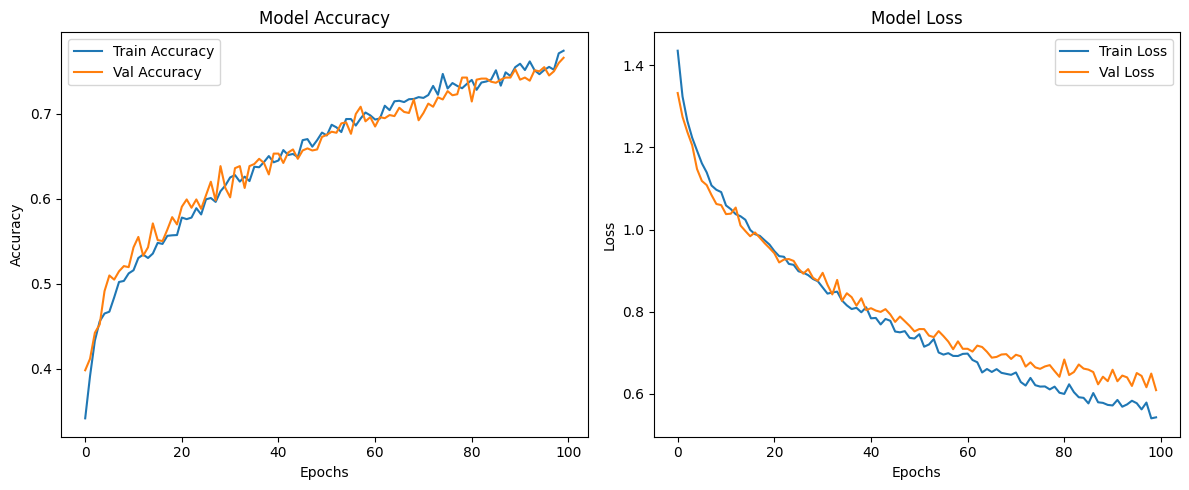

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# === 1. Plot accuracy and loss curves ===
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()





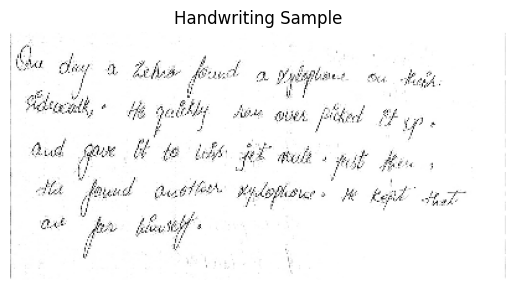

In [ ]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# === Load the handwriting image ===
image_path = '/content/vikash19eng-1-1.jpg'  #
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (400, 200))
plt.imshow(image, cmap='gray')
plt.title("Handwriting Sample")
plt.axis('off')
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib
import numpy as np

# Load the classes (Fixing the allow_pickle error)
classes = np.load('classes.npy', allow_pickle=True)

# === Feature Extraction Function (Mocked) ===
def extract_features(image_path):
    # Load grayscale image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("Image not loaded. Check path.")

    # Resize to fixed size (standardize input)
    img = cv2.resize(img, (256, 256))

    # === Feature extraction logic (mocked here with random values) ===
    # Replace these random values with real extracted feature formulas
    feature_vector = [
        np.mean(img) % 90,                  # Feature 1: Slant Angle (mocked)
        np.std(img),                        # Feature 2: Letter Spacing
        np.max(img) / 255,                  # Feature 3: Pressure
        np.var(img),                        # Feature 4: Line Alignment
        np.sum(img % 10) / 1000,            # Feature 5: Loop Formation
        np.mean(np.diff(img[:50])),         # Feature 6: Stroke Smoothness
        np.std(img[::10]),                  # Feature 7: Word Spacing
        np.mean(img[::15]),                 # Feature 8: Letter Size Consistency
        np.count_nonzero(img == 0) / 1000,  # Feature 9: Pen Lift (mocked)
        np.mean(img[::20]),                 # Feature 10: Legibility
        np.median(img[::30]),               # Feature 11: Cursive Print
        np.mean(np.abs(np.diff(img[::10]))),# Feature 12: Speed Fluctuation
        np.mean(img[:, :10]),               # Feature 13: Pen Tilt
        np.mean(img[:, -10:]),              # Feature 14: Ink Darkness
        np.sum(img) % 10                    # Feature 15: Strokes Per Letter
    ]

    return feature_vector

# === Prediction Function ===
def predict_personality_from_image(image_path):
    # Extract 15 features from image
    features = extract_features(image_path)

    feature_names = [
        'Feature_1_Slant_Angle',
        'Feature_2_Letter_Spacing',
        'Feature_3_Pressure',
        'Feature_4_Line_Alignment',
        'Feature_5_Loop_Formation',
        'Feature_6_Stroke_Smoothness',
        'Feature_7_Word_Spacing',
        'Feature_8_Letter_Size_Consistency',
        'Feature_9_Pen_Lift',
        'Feature_10_Legibility',
        'Feature_11_Cursive_Print',
        'Feature_12_Speed_Fluctuation',
        'Feature_13_Pen_Tilt',
        'Feature_14_Ink_Darkness',
        'Feature_15_Strokes_Per_Letter',
    ]

    print("\n📝 Extracted Feature Values:")
    for name, val in zip(feature_names, features):
        print(f"{name}: {val:.4f}")

    # === Normalize features ===
    scaler = joblib.load('/content/scaler.pkl')
    features_scaled = scaler.transform([features])

    # === Load model & predict ===
    model = load_model('/content/deep_learning_model.h5')
    probs = model.predict(features_scaled)
    pred_index = np.argmax(probs)
    pred_label = classes[pred_index]

    print("\n🧠 Personality Prediction:")
    print(f"→ Predicted Personality: **{pred_label}**")
    print(f"→ Prediction Confidence: {probs[0][pred_index]:.2%}")

# === Call function with your sample image path ===
predict_personality_from_image('/content/vikash19eng-1-1.jpg')



📝 Extracted Feature Values:
Feature_1_Slant_Angle: 67.0728
Feature_2_Letter_Spacing: 32.7249
Feature_3_Pressure: 1.0000
Feature_4_Line_Alignment: 1070.9171
Feature_5_Loop_Formation: 318.3060
Feature_6_Stroke_Smoothness: 29.4509
Feature_7_Word_Spacing: 32.1764
Feature_8_Letter_Size_Consistency: 247.0423
Feature_9_Pen_Lift: 0.0260
Feature_10_Legibility: 246.5355
Feature_11_Cursive_Print: 255.0000
Feature_12_Speed_Fluctuation: 30.0739
Feature_13_Pen_Tilt: 246.6984
Feature_14_Ink_Darkness: 253.6867
Feature_15_Strokes_Per_Letter: 6.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

🧠 Personality Prediction:
→ Predicted Personality: **Neuroticism**
→ Prediction Confidence: 100.00%
